# Exploração de Dados — Detecção de Fraudes em Compras

## TDE 01

Este notebook apresenta a exploração inicial dos dados do projeto de **Detecção de Fraudes em Compras**, utilizando o dataset **IEEE-CIS Fraud Detection**.

O objetivo desta etapa é conhecer a estrutura dos dados, verificar sua qualidade e observar características relevantes das transações e da variável `isFraud`.

## 1. Preparação do ambiente

In [1]:
# Execute esta célula apenas se as bibliotecas ainda não estiverem instaladas.
# Ela instala as bibliotecas necessárias para executar o notebook.

import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "pandas", "matplotlib", "seaborn"
])

0

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

Matplotlib is building the font cache; this may take a moment.


## 2. Carregamento dos dados

In [2]:
# Os arquivos devem estar dentro da pasta data/
# Estrutura esperada:
# data/train_transaction.csv
# data/train_identity.csv

transacoes = pd.read_csv("data/train_transaction.csv")
identidade = pd.read_csv("data/train_identity.csv")

print("Dados de transações:", transacoes.shape)
print("Dados de identidade:", identidade.shape)

Dados de transações: (590540, 394)
Dados de identidade: (144233, 41)


## 3. Visualização inicial

In [3]:
transacoes.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
identidade.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


## 4. Estrutura e tipos dos dados

In [5]:
print("Tipos de dados — transações:")
display(transacoes.dtypes.value_counts())

print("\nTipos de dados — identidade:")
display(identidade.dtypes.value_counts())

Tipos de dados — transações:


float64    376
str         14
int64        4
Name: count, dtype: int64


Tipos de dados — identidade:


float64    23
str        17
int64       1
Name: count, dtype: int64

In [6]:
print("Número de colunas em transações:", len(transacoes.columns))
print("Número de colunas em identidade:", len(identidade.columns))

print("\nColunas das transações:")
display(transacoes.columns.tolist())

Número de colunas em transações: 394
Número de colunas em identidade: 41

Colunas das transações:


['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

## 5. Valores ausentes

In [7]:
faltantes_transacoes = (
    transacoes.isna()
    .sum()
    .sort_values(ascending=False)
)

faltantes_transacoes.head(20)

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V149     508595
V141     508595
V146     508595
V154     508595
V162     508595
V142     508595
V158     508595
V161     508595
V157     508595
V138     508595
V139     508595
dtype: int64

In [8]:
faltantes_identidade = (
    identidade.isna()
    .sum()
    .sort_values(ascending=False)
)

faltantes_identidade.head(20)

id_24         139486
id_25         139101
id_07         139078
id_08         139078
id_21         139074
id_26         139070
id_23         139064
id_27         139064
id_22         139064
id_18          99120
id_04          77909
id_03          77909
id_33          70944
id_10          69307
id_09          69307
id_30          66668
id_32          66647
id_34          66428
id_14          64189
DeviceInfo     25567
dtype: int64

## 6. Registros duplicados

In [9]:
print("Duplicados em transações:", transacoes.duplicated().sum())
print("Duplicados em identidade:", identidade.duplicated().sum())

Duplicados em transações: 0
Duplicados em identidade: 0


## 7. Variável alvo: isFraud

In [10]:
transacoes["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [11]:
contagem_fraude = transacoes["isFraud"].value_counts()
percentual_fraude = transacoes["isFraud"].value_counts(normalize=True) * 100

resultado_fraude = pd.DataFrame({
    "Quantidade": contagem_fraude,
    "Percentual (%)": percentual_fraude.round(2)
})

resultado_fraude

,Quantidade,Percentual (%)
isFraud,,
0,569877,96.5
1,20663,3.5


In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=transacoes, x="isFraud")
plt.title("Distribuição das Transações por Status de Fraude")
plt.xlabel("Fraude (0 = Não, 1 = Sim)")
plt.ylabel("Quantidade")
plt.show()

## 8. Análise da variável TransactionAmt

In [12]:
transacoes["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

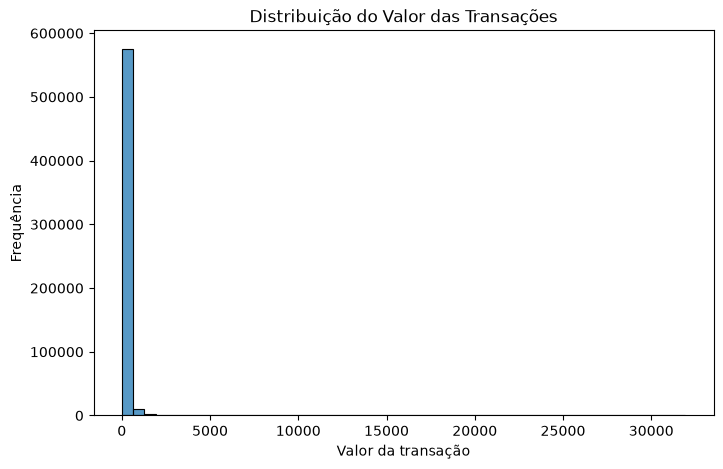

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=transacoes,
    x="TransactionAmt",
    bins=50
)
plt.title("Distribuição do Valor das Transações")
plt.xlabel("Valor da transação")
plt.ylabel("Frequência")
plt.show()

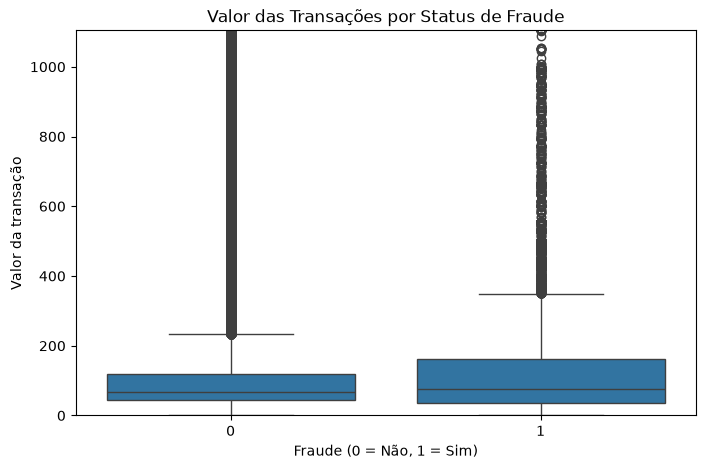

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=transacoes,
    x="isFraud",
    y="TransactionAmt"
)
plt.title("Valor das Transações por Status de Fraude")
plt.xlabel("Fraude (0 = Não, 1 = Sim)")
plt.ylabel("Valor da transação")
plt.ylim(0, transacoes["TransactionAmt"].quantile(0.99))
plt.show()

## 9. Relação entre tempo e fraude

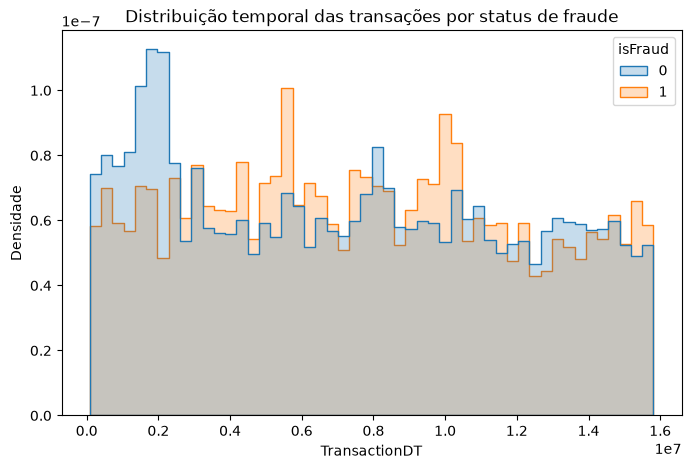

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=transacoes,
    x="TransactionDT",
    hue="isFraud",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Distribuição temporal das transações por status de fraude")
plt.xlabel("TransactionDT")
plt.ylabel("Densidade")
plt.show()

## 10. Algumas variáveis categóricas

In [16]:
colunas_categoricas = [
    coluna for coluna in ["ProductCD", "card4", "card6"]
    if coluna in transacoes.columns
]

for coluna in colunas_categoricas:
    print(f"\n{coluna}:")
    display(transacoes[coluna].value_counts(dropna=False).head(10))


ProductCD:


ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


card4:


card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64


card6:


card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64

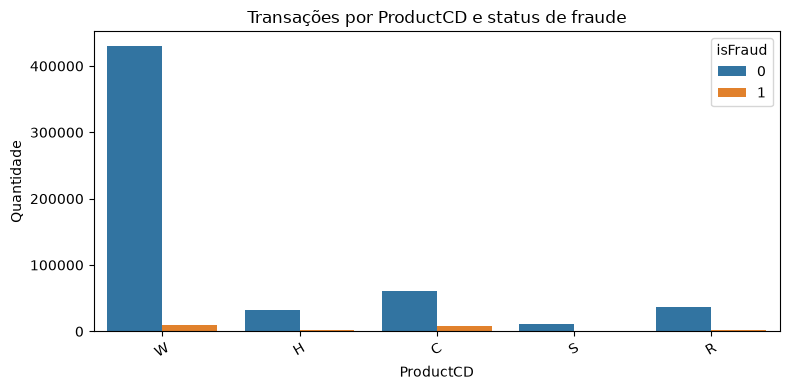

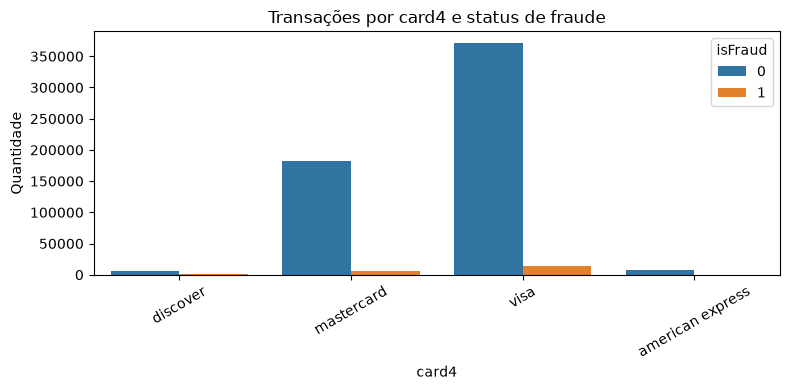

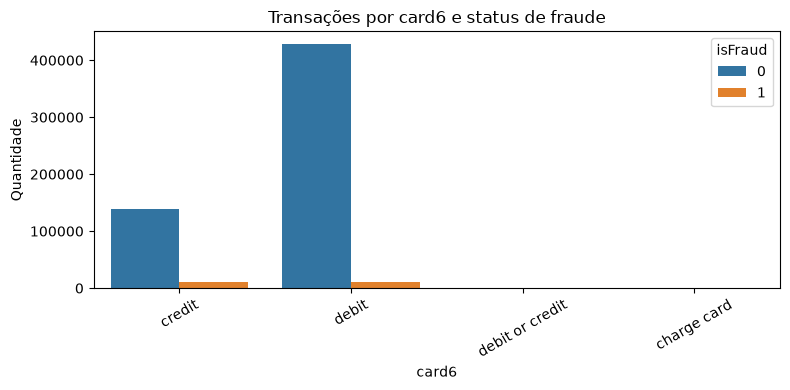

In [17]:
for coluna in colunas_categoricas:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=transacoes,
        x=coluna,
        hue="isFraud"
    )
    plt.title(f"Transações por {coluna} e status de fraude")
    plt.xlabel(coluna)
    plt.ylabel("Quantidade")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 11. Relação entre os arquivos

In [18]:
print("TransactionID é a chave utilizada para relacionar os arquivos de transação e identidade.")

ids_transacoes = transacoes["TransactionID"].nunique()
ids_identidade = identidade["TransactionID"].nunique()

print("TransactionIDs únicos em transações:", ids_transacoes)
print("TransactionIDs únicos em identidade:", ids_identidade)

ids_com_identidade = transacoes["TransactionID"].isin(
    identidade["TransactionID"]
).sum()

print("Transações com registro correspondente de identidade:", ids_com_identidade)
print(
    "Percentual com identidade: "
    f"{ids_com_identidade / len(transacoes) * 100:.2f}%"
)

TransactionID é a chave utilizada para relacionar os arquivos de transação e identidade.
TransactionIDs únicos em transações: 590540
TransactionIDs únicos em identidade: 144233
Transações com registro correspondente de identidade: 144233
Percentual com identidade: 24.42%


## 12. Conclusões da exploração

A exploração inicial permitiu identificar características importantes das bases utilizadas no projeto de detecção de fraudes em compras.

A base de transações possui 590.540 registros, sendo 569.877 transações não fraudulentas (96,5%) e 20.663 fraudulentas (3,5%). Isso evidencia um forte desbalanceamento da variável alvo `isFraud`, que deve ser considerado nas etapas posteriores de modelagem e avaliação dos modelos.

A variável `TransactionAmt` apresentou grande variação nos valores das transações. A mediana foi de aproximadamente 68,77, enquanto o valor máximo chegou a 31.937,39. A distribuição apresentou forte concentração em valores menores e presença de valores extremos.

Na análise temporal, as distribuições das transações fraudulentas e não fraudulentas apresentaram comportamentos semelhantes em diferentes períodos. Dessa forma, apenas a visualização temporal não indica uma separação clara entre os dois grupos.

Entre as variáveis categóricas analisadas, o `ProductCD` apresentou predominância do produto W, seguido por C, R, H e S. Para `card4`, a maior parte das transações utilizou Visa e Mastercard. Já em `card6`, houve predominância de cartões de débito em relação aos cartões de crédito.

A análise da relação entre os arquivos mostrou que `TransactionID` é utilizado como chave de relacionamento entre os dados de transações e identidade. Foram identificados 590.540 IDs únicos na base de transações e 144.233 IDs únicos na base de identidade. O código de análise encontrou correspondência para 144.233 registros, representando aproximadamente 24,42% da base de transações.

Portanto, a exploração mostrou que os dados apresentam desbalanceamento significativo entre transações fraudulentas e não fraudulentas, valores de transação com forte assimetria, presença de valores extremos e grande quantidade de informações ausentes ou sem correspondência de identidade. Essas características deverão ser consideradas nas etapas seguintes de preparação dos dados e desenvolvimento do modelo de detecção de fraudes.